# PyTorch Neural Network Model

This notebook trains a multilayer perceptron using PyTorch to compare with the XGBoost baseline.

**Output:** Trained model saved to `models/pytorch_model.pt`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv', index_col=0)
X_test = pd.read_csv('../data/processed/X_test.csv', index_col=0)
y_train = pd.read_csv('../data/processed/y_train.csv', index_col=0).squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv', index_col=0).squeeze()

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (567, 1000)
Test: (142, 1000)


In [3]:
pip install torch

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 27.2 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 94.7 MB/s eta 0:00:00
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [torch]━━━━━ 5/6 [torch]]x]mpy]

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [5]:
class GeneExpressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values)
        self.y = torch.FloatTensor(y.values).reshape(-1, 1)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = GeneExpressionDataset(X_train, y_train)
test_dataset = GeneExpressionDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 18
Test batches: 5


/var/folders/m9/s0zm7jbj5hq1pxg8_vdyyhhm0000gn/T/ipykernel_86831/1501554515.py:4: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self.y = torch.FloatTensor(y.values).reshape(-1, 1)


In [6]:
class DrugResponseMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

input_size = X_train.shape[1]
model = DrugResponseMLP(input_size).to(device)
print(model)

DrugResponseMLP(
  (layers): Sequential(
    (0): Linear(in_features=1000, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [7]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 100
train_losses = []
val_losses = []

In [8]:
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    train_loss = epoch_loss / len(train_loader)
    train_losses.append(train_loss)
    
    model.eval()
    with torch.no_grad():
        val_loss = 0
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            val_loss += criterion(y_pred, y_batch).item()
        val_loss = val_loss / len(test_loader)
        val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 10/100 | Train Loss: 0.4428 | Val Loss: 1.8520
Epoch 20/100 | Train Loss: 0.3535 | Val Loss: 2.1152
Epoch 30/100 | Train Loss: 0.2324 | Val Loss: 1.9919
Epoch 40/100 | Train Loss: 0.2343 | Val Loss: 1.9117
Epoch 50/100 | Train Loss: 0.1960 | Val Loss: 1.9644
Epoch 60/100 | Train Loss: 0.1922 | Val Loss: 1.9419
Epoch 70/100 | Train Loss: 0.1766 | Val Loss: 1.7961
Epoch 80/100 | Train Loss: 0.1896 | Val Loss: 1.9891
Epoch 90/100 | Train Loss: 0.1605 | Val Loss: 1.8629
Epoch 100/100 | Train Loss: 0.1490 | Val Loss: 1.9020


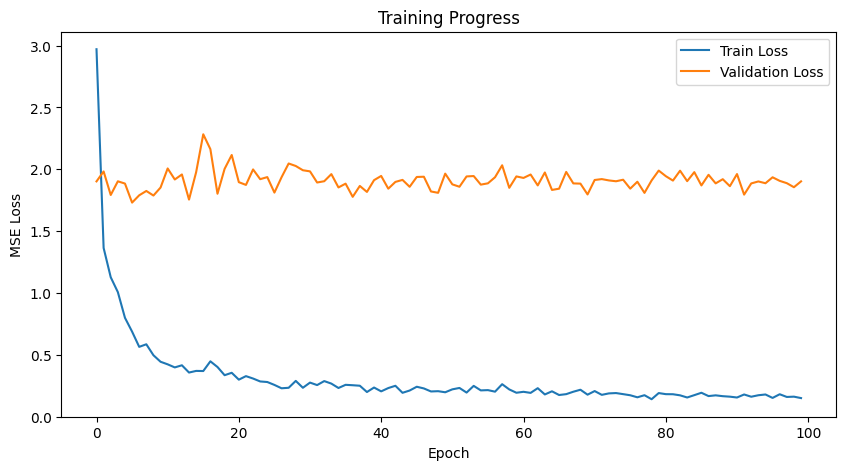

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Progress')
plt.legend()
plt.savefig('../reports/figures/pytorch_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test.values).to(device)
    y_pred_nn = model(X_test_tensor).cpu().numpy().flatten()

r2_nn = r2_score(y_test, y_pred_nn)
corr_nn, _ = pearsonr(y_test, y_pred_nn)

print(f"PyTorch R2: {r2_nn:.4f}")
print(f"PyTorch Pearson: {corr_nn:.4f}")

PyTorch R2: 0.1707
PyTorch Pearson: 0.4947


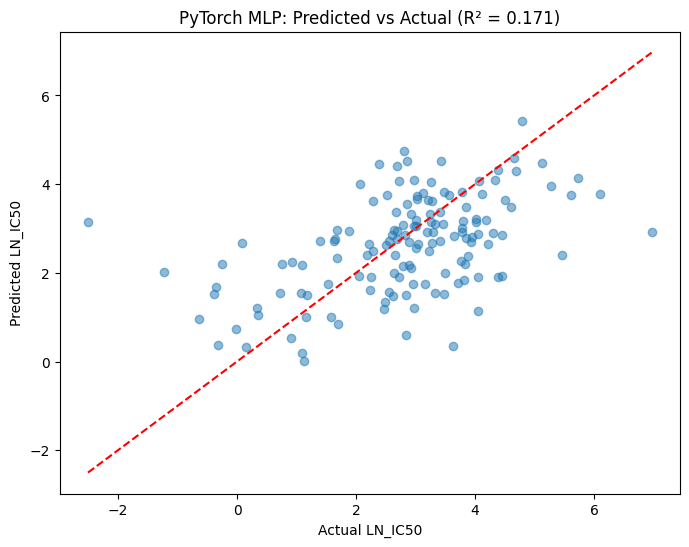

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_nn, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual LN_IC50')
plt.ylabel('Predicted LN_IC50')
plt.title(f'PyTorch MLP: Predicted vs Actual (R² = {r2_nn:.3f})')
plt.savefig('../reports/figures/pytorch_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
import joblib

xgb_model = joblib.load('../models/xgboost_model.joblib')
y_pred_xgb = xgb_model.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)
corr_xgb, _ = pearsonr(y_test, y_pred_xgb)

print("="*50)
print("MODEL COMPARISON")
print("="*50)
print(f"{'Model':<20} {'R2':<10} {'Pearson':<10}")
print("-"*50)
print(f"{'XGBoost (tuned)':<20} {r2_xgb:.4f}     {corr_xgb:.4f}")
print(f"{'PyTorch MLP':<20} {r2_nn:.4f}     {corr_nn:.4f}")
print("="*50)

MODEL COMPARISON
Model                R2         Pearson   
--------------------------------------------------
XGBoost (tuned)      0.1849     0.4391
PyTorch MLP          0.1707     0.4947


In [17]:
torch.save(model.state_dict(), '../models/pytorch_model.pt')
print("PyTorch model saved")

PyTorch model saved


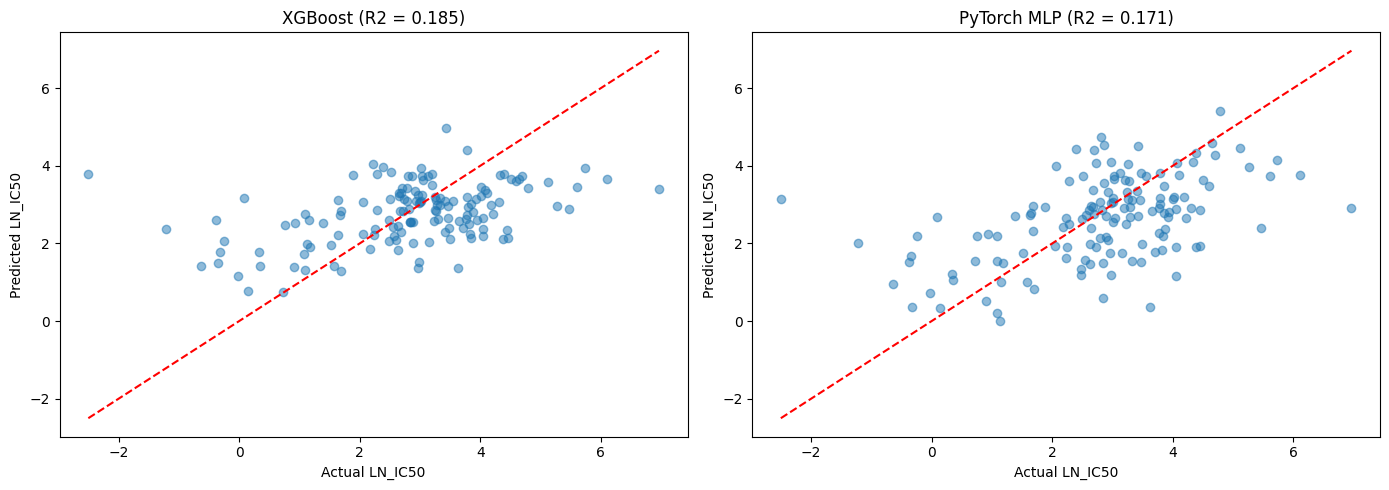

In [19]:
import joblib

xgb_model = joblib.load('../models/xgboost_model.joblib')
y_pred_xgb = xgb_model.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_xgb, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual LN_IC50')
axes[0].set_ylabel('Predicted LN_IC50')
axes[0].set_title(f'XGBoost (R2 = {r2_xgb:.3f})')

axes[1].scatter(y_test, y_pred_nn, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual LN_IC50')
axes[1].set_ylabel('Predicted LN_IC50')
axes[1].set_title(f'PyTorch MLP (R2 = {r2_nn:.3f})')

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()